In [1]:
import numpy as np
import matplotlib.pylab as plt

#Take variables from Block_ files
%store -r lsCGTBl1
%store -r lsCGTBl5
%store -r lsCGTBl10
%store -r lsCGTBl50

In [2]:
ls = [lsCGTBl1, lsCGTBl5, lsCGTBl10, lsCGTBl50]
config = ['1', '5', '10', '50']

In [3]:
# Theory
x = np.linspace(0.1, 30)
y = 1 / np.tanh(x) - 1 / x

#Critical temperature (Gihwan's data)
Tc = [0.41, 0.85, 1.09, 1.6]

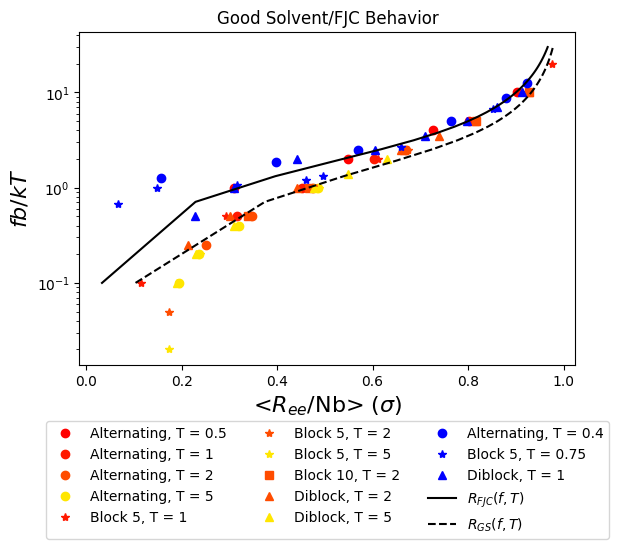

In [ ]:
#High T behavior
import matplotlib as mpl

symbol = ['o','*', 's', '^']
sequence = ['Alternating', 'Block 5', 'Block 10', 'Diblock']

cmap = mpl.colormaps['autumn']
fig, ax = plt.subplots(layout='constrained')
T_theta = [0.4, 0.75, 1, 1]

def normalize(t):
    return (t-0.5)/5

for i in range(0, 4):
    cgt = ls[i]
    force = np.array([])
    Ree = np.array([])    

    for test in cgt:
        if test.t > Tc[i]:
            Ree = test.aveRee
            force = test.f
            ax.plot((Ree / 99), force/test.t, symbol[i], color=cmap(normalize(test.t)), label = f'{sequence[i]}, T = {test.t}')


for i in range(0, 4):
    for cgt in ls[i]:
        if cgt.t == T_theta[i]:
            plt.plot(cgt.aveRee / 99, cgt.f/cgt.t, symbol[i], color = 'blue', label = f'{sequence[i]}, T = {T_theta[i]}')

#FJC and real chain models
plt.plot(y, x, 'k', label = '$R_{FJC}(f, T)$')
plt.plot(y**(2/3), x, 'k--', label = '$R_{GS}(f, T)$')

box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,box.width, box.height * 0.9])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),fancybox=True, ncol=3)

plt.ylabel('$fb/kT$', fontsize=16)
plt.xlabel('<$R_{ee}$/Nb> ($\sigma$)', fontsize=16)
plt.yscale('log')
plt.title(r'Good Solvent/FJC Behavior')
plt.show()